# Assignment 10.1 - Convolutional Neural Networks

Please submit your solution of this notebook in the Whiteboard at the corresponding Assignment entry as .ipynb-file and as .pdf.

#### Please state both names of your group members here:
Rashid Harvey and S M Shameem Ahmed Khan

## Task 10.1.1: Training a CNN

First, we recommend using PyTorch for this assignment, a popular machine learning framework. Should be able to install it according to the official instructions on [pytorch.org](https://pytorch.org/).

It might be useful to use [Google Colab](https://colab.research.google.com), too. Google offers some compute, so you are not stuck running your programs locally. You can even use GPUs and TPUs! For this assignment, your local machine should be enough, though. In Google Colab variables might get lost when your computer disconnects from the internet or the notebook runs idle for a while. 

Browse through the [pytorch tutorials ](https://pytorch.org/tutorials/), they often come as colab notebooks - go and execute some!

* Set up your own convolutionnal network of the following structure **(RESULT)**: 
    * 3 convolution layers 
    * 2 fully connected layers 
* Use some padding, stride, pooling, drop out and batch normalization. You should use the ReLU activation function.  **(RESULT)**
* Initialize your model, build a train and test function and display the model's performance on the MNIST classification task. **(RESULT)**

In [1]:
# imports
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
import sys
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Some hyperparameters that might be useful for the neural network 
# (adapt them to your needs)

n_epochs = 5    # Total number of training iterations
batch_size_train = 128   # Number of training samples utilized per iteration
batch_size_test = 1000  # Number of test samples utilized per iteration
learning_rate = 0.01
momentum = 0.9  # Momentum for the optimizer (if applicable)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
# Prepare MNIST data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

# Download and load training data
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size_train, shuffle=True
)

# Download and load test data
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size_test, shuffle=False
)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")

Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])


In [4]:
# Define our model class `CNN` which extends from `torch.nn.Module`.
class CNN(torch.nn.Module):
    def __init__(self, D_out=10):
        super(CNN, self).__init__()
        
        # Convolutional Layer 1: 1 input channel, 32 output channels, 3x3 kernel
        # Input: 1x28x28 -> Output: 32x28x28 (with padding=1)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # Convolutional Layer 2: 32 input channels, 64 output channels, 3x3 kernel
        # After pool1: 32x14x14 -> Output: 64x14x14 (with padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Convolutional Layer 3: 64 input channels, 128 output channels, 3x3 kernel
        # After pool2: 64x7x7 -> Output: 128x7x7 (with padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Max pooling layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Dropout layer
        # https://de.wikipedia.org/wiki/Dropout_(k%C3%BCnstliches_neuronales_Netz)
        self.dropout = nn.Dropout(0.5)
        
        # Fully connected layers
        # After conv3 and pool3: 128x3x3 = 1152 features
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, D_out)

    def forward(self, x):
        # Conv1 -> BatchNorm -> ReLU -> Pool
        # 1x28x28 -> 32x28x28 -> 32x14x14
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        
        # Conv2 -> BatchNorm -> ReLU -> Pool
        # 32x14x14 -> 64x14x14 -> 64x7x7
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        
        # Conv3 -> BatchNorm -> ReLU -> Pool
        # 64x7x7 -> 128x7x7 -> 128x3x3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        
        # Flatten
        x = x.view(-1, 128 * 3 * 3)
        
        # FC1 -> ReLU -> Dropout
        x = self.dropout(F.relu(self.fc1(x)))
        
        # FC2 (output layer)
        x = self.fc2(x)
        
        return x


def train_model(model, train_loader, optimizer, criterion, device):
    """Training function for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = output.max(1)
        total += target.size(0)
        correct += predicted.eq(target).sum().item()
    
    accuracy = 100. * correct / total
    avg_loss = running_loss / len(train_loader)
    return avg_loss, accuracy


def test_model(model, test_loader, criterion, device):
    """Testing function"""
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            
            test_loss += loss.item()
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()
    
    accuracy = 100. * correct / total
    avg_loss = test_loss / len(test_loader)
    return avg_loss, accuracy

In [7]:
# Initialize CNN model and train
cnn_model = CNN(D_out=10).to(device)
criterion = nn.CrossEntropyLoss()
# stochastic gradient descent
optimizer = torch.optim.SGD(cnn_model.parameters(), lr=learning_rate, momentum=momentum)

# Count parameters
cnn_params = sum(p.numel() for p in cnn_model.parameters())
print(f"CNN Model Parameters: {cnn_params:,}")
print(f"Using device: {device}")
print(cnn_model)

# Training loop
print("\nTraining CNN...")
for epoch in range(1, n_epochs + 1):
    train_loss, train_acc = train_model(cnn_model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = test_model(cnn_model, test_loader, criterion, device)
    print(f"Epoch {epoch}/{n_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

CNN Model Parameters: 390,858
Using device: cpu
CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

Training CNN...
Epoch 1/5 - Train Loss: 0.1938, Train Acc: 94.08% | Test Loss: 0.0412, Test Acc: 98.64%
Epoch 2/5 - Train Loss: 0.0549, Train Acc: 98.31% | Test Loss: 0.0297, Test Acc: 99.01%
E

## Task 10.1.2: Compare vs fully connected network

* Compare the performance of your CNN to a fully connected network of similar size (number of parameters). **(RESULT)**
* Plot training and test accuracy/loss curves for both models. Train each for 2 epochs. **(RESULT)**

In [8]:
# Task 10.1.2: Compare CNN to a fully connected network of similar size

# Define Fully Connected Network with similar number of parameters as CNN
class FullyConnectedNet(nn.Module):
    def __init__(self, D_out=10):
        super(FullyConnectedNet, self).__init__()
        
        # MNIST images are 28x28 = 784 input features
        # Design FC network with similar parameter count to CNN (~400k parameters)
        self.fc1 = nn.Linear(784, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.fc4 = nn.Linear(128, D_out)
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        # Flatten input
        x = x.view(-1, 784)
        
        # FC1 -> BatchNorm -> ReLU -> Dropout
        x = self.dropout(F.relu(self.bn1(self.fc1(x))))
        
        # FC2 -> BatchNorm -> ReLU -> Dropout
        x = self.dropout(F.relu(self.bn2(self.fc2(x))))
        
        # FC3 -> BatchNorm -> ReLU -> Dropout
        x = self.dropout(F.relu(self.bn3(self.fc3(x))))
        
        # FC4 (output layer)
        x = self.fc4(x)
        
        return x


def train_and_track(model, train_loader, test_loader, optimizer, criterion, device, n_epochs):
    """Train model and track metrics over epochs"""
    train_losses, test_losses = [], []
    train_accs, test_accs = [], []
    
    for epoch in range(1, n_epochs + 1):
        train_loss, train_acc = train_model(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc = test_model(model, test_loader, criterion, device)
        
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        
        print(f"Epoch {epoch}/{n_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")
    
    return train_losses, test_losses, train_accs, test_accs


# Initialize both models
n_epochs_compare = 2  # Train for 2 epochs as specified

# CNN Model
cnn_compare = CNN(D_out=10).to(device)
cnn_optimizer = torch.optim.SGD(cnn_compare.parameters(), lr=learning_rate, momentum=momentum)

# Fully Connected Model
fc_model = FullyConnectedNet(D_out=10).to(device)
fc_optimizer = torch.optim.SGD(fc_model.parameters(), lr=learning_rate, momentum=momentum)

# Count parameters for comparison
cnn_params = sum(p.numel() for p in cnn_compare.parameters())
fc_params = sum(p.numel() for p in fc_model.parameters())

print(f"CNN Parameters: {cnn_params:,}")
print(f"FC Network Parameters: {fc_params:,}")
print(f"Parameter ratio (FC/CNN): {fc_params/cnn_params:.2f}")

# Train CNN
print("\n" + "="*60)
print("Training CNN for 2 epochs...")
print("="*60)
cnn_train_losses, cnn_test_losses, cnn_train_accs, cnn_test_accs = train_and_track(
    cnn_compare, train_loader, test_loader, cnn_optimizer, criterion, device, n_epochs_compare
)

# Train FC Network
print("\n" + "="*60)
print("Training Fully Connected Network for 2 epochs...")
print("="*60)
fc_train_losses, fc_test_losses, fc_train_accs, fc_test_accs = train_and_track(
    fc_model, train_loader, test_loader, fc_optimizer, criterion, device, n_epochs_compare
)



CNN Parameters: 390,858
FC Network Parameters: 569,226
Parameter ratio (FC/CNN): 1.46

Training CNN for 2 epochs...
Epoch 1/2 - Train Loss: 0.1933, Train Acc: 94.16% | Test Loss: 0.0432, Test Acc: 98.57%
Epoch 2/2 - Train Loss: 0.0551, Train Acc: 98.36% | Test Loss: 0.0327, Test Acc: 98.99%

Training Fully Connected Network for 2 epochs...
Epoch 1/2 - Train Loss: 0.5592, Train Acc: 83.27% | Test Loss: 0.1612, Test Acc: 95.17%
Epoch 2/2 - Train Loss: 0.2683, Train Acc: 92.19% | Test Loss: 0.1174, Test Acc: 96.36%


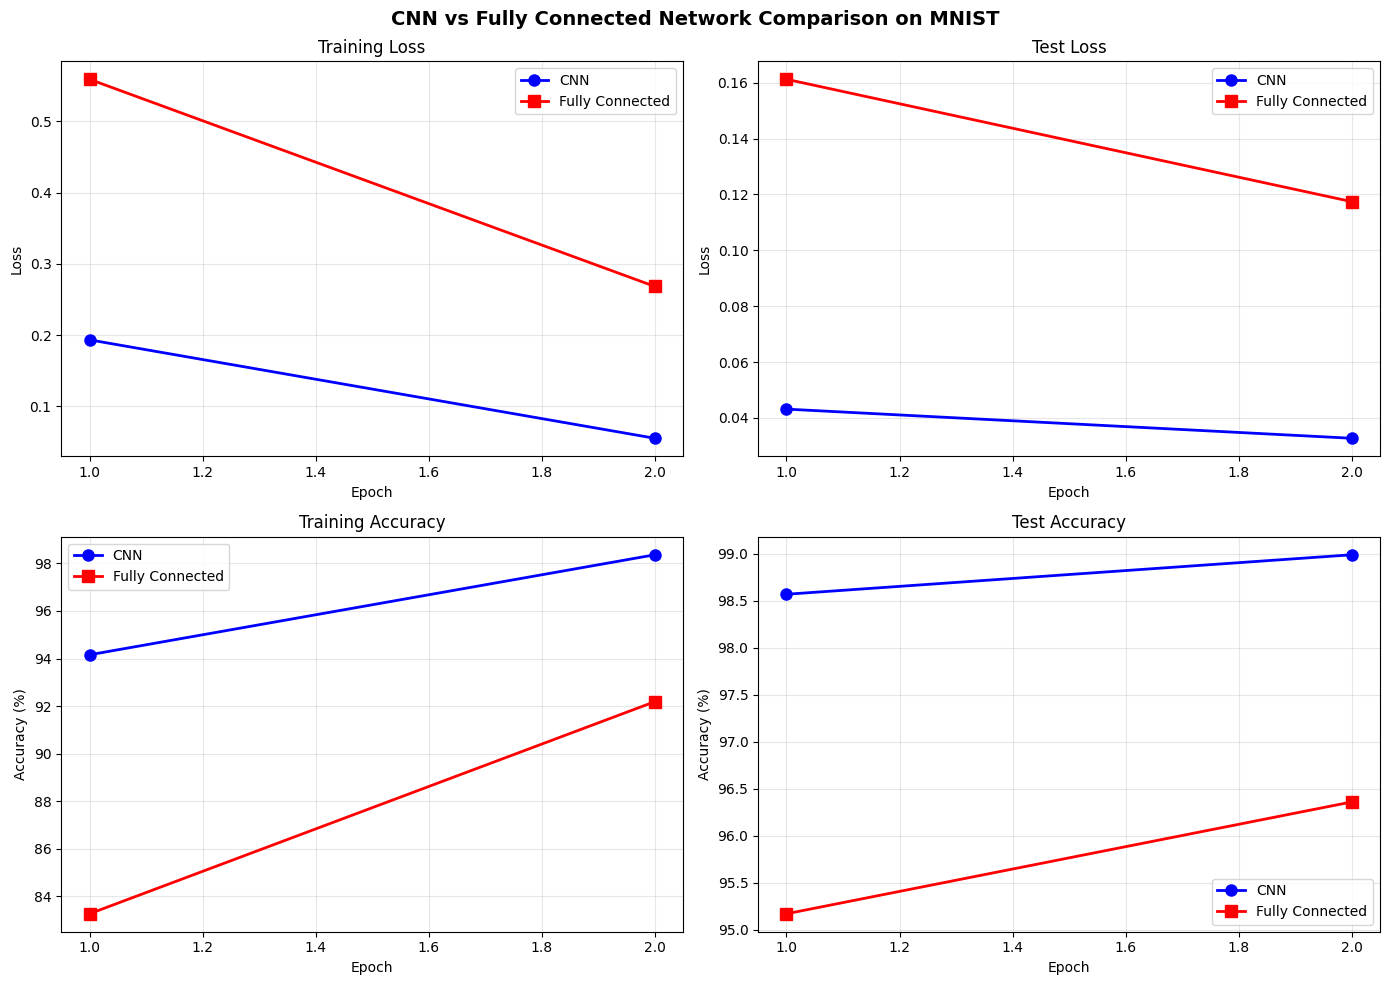


SUMMARY AFTER 2 EPOCHS

CNN:
  Parameters: 390,858
  Final Train Accuracy: 98.36%
  Final Test Accuracy: 98.99%
  Final Test Loss: 0.0327

Fully Connected Network:
  Parameters: 569,226
  Final Train Accuracy: 92.19%
  Final Test Accuracy: 96.36%
  Final Test Loss: 0.1174

Conclusion:
  CNN outperforms FC by 2.63% on test accuracy
  CNNs are better for image data due to their ability to capture spatial features


In [10]:
# Plot comparison
fig, ((ax00, ax01), (ax10, ax11)) = plt.subplots(2, 2, figsize=(14, 10))
epochs = range(1, n_epochs_compare + 1)

# Training Loss
ax00.plot(epochs, cnn_train_losses, 'b-o', label='CNN', linewidth=2, markersize=8)
ax00.plot(epochs, fc_train_losses, 'r-s', label='Fully Connected', linewidth=2, markersize=8)
ax00.set_xlabel('Epoch')
ax00.set_ylabel('Loss')
ax00.set_title('Training Loss')
ax00.legend()
ax00.grid(True, alpha=0.3)

# Test Loss
ax01.plot(epochs, cnn_test_losses, 'b-o', label='CNN', linewidth=2, markersize=8)
ax01.plot(epochs, fc_test_losses, 'r-s', label='Fully Connected', linewidth=2, markersize=8)
ax01.set_xlabel('Epoch')
ax01.set_ylabel('Loss')
ax01.set_title('Test Loss')
ax01.legend()
ax01.grid(True, alpha=0.3)

# Training Accuracy
ax10.plot(epochs, cnn_train_accs, 'b-o', label='CNN', linewidth=2, markersize=8)
ax10.plot(epochs, fc_train_accs, 'r-s', label='Fully Connected', linewidth=2, markersize=8)
ax10.set_xlabel('Epoch')
ax10.set_ylabel('Accuracy (%)')
ax10.set_title('Training Accuracy')
ax10.legend()
ax10.grid(True, alpha=0.3)

# Test Accuracy
ax11.plot(epochs, cnn_test_accs, 'b-o', label='CNN', linewidth=2, markersize=8)
ax11.plot(epochs, fc_test_accs, 'r-s', label='Fully Connected', linewidth=2, markersize=8)
ax11.set_xlabel('Epoch')
ax11.set_ylabel('Accuracy (%)')
ax11.set_title('Test Accuracy')
ax11.legend()
ax11.grid(True, alpha=0.3)
plt.suptitle('CNN vs Fully Connected Network Comparison on MNIST', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*60)
print("SUMMARY AFTER 2 EPOCHS")
print("="*60)
print(f"\nCNN:")
print(f"  Parameters: {cnn_params:,}")
print(f"  Final Train Accuracy: {cnn_train_accs[-1]:.2f}%")
print(f"  Final Test Accuracy: {cnn_test_accs[-1]:.2f}%")
print(f"  Final Test Loss: {cnn_test_losses[-1]:.4f}")

print(f"\nFully Connected Network:")
print(f"  Parameters: {fc_params:,}")
print(f"  Final Train Accuracy: {fc_train_accs[-1]:.2f}%")
print(f"  Final Test Accuracy: {fc_test_accs[-1]:.2f}%")
print(f"  Final Test Loss: {fc_test_losses[-1]:.4f}")

print(f"\nConclusion:")
print(f"  CNN outperforms FC by {cnn_test_accs[-1] - fc_test_accs[-1]:.2f}% on test accuracy")
print(f"  CNNs are better for image data due to their ability to capture spatial features")

## Congratz, you made it! :)